In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (284807, 31)


In [4]:
print(f"\nFirst 5 rows:")
df.head()


First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [6]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [7]:
print('Missing values:', df.isnull().sum())
print(df.dtypes)

Missing values: Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


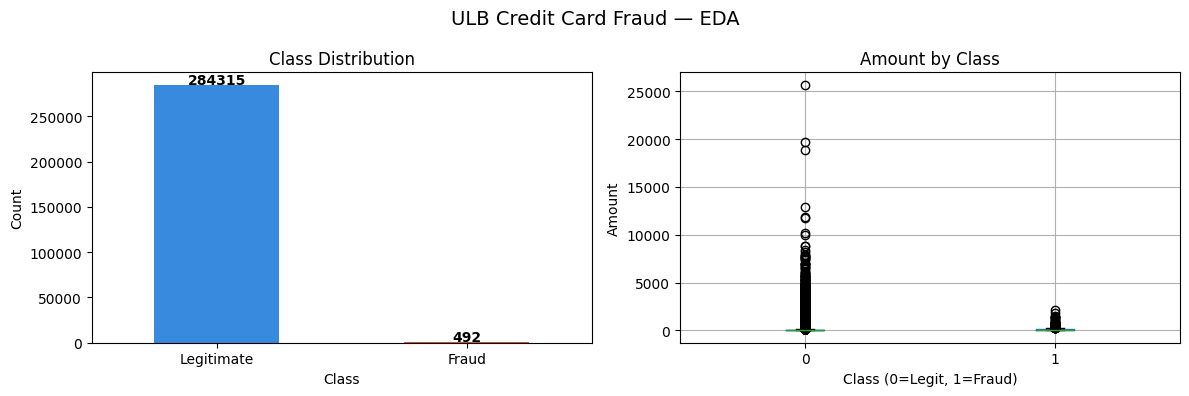

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
df['Class'].value_counts().plot(kind='bar', ax=axes[0],
                                color=['#378ADD', '#E24B4A'])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[0].set_ylabel('Count')
for i, v in enumerate(df['Class'].value_counts()):
    axes[0].text(i, v + 1000, str(v), ha='center', fontweight='bold')

# Amount distribution by class
df.boxplot(column='Amount', by='Class', ax=axes[1])
axes[1].set_title('Amount by Class')
axes[1].set_xlabel('Class (0=Legit, 1=Fraud)')
axes[1].set_ylabel('Amount')

plt.suptitle('ULB Credit Card Fraud — EDA', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])

# Drop original Amount and Time
df = df.drop(['Amount', 'Time'], axis=1)

print(df.shape)
print(df.head())

(284807, 31)
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  0.207643  ...  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28  Class  Amount_scaled  

In [10]:
print(df.columns.tolist())
print(df.shape)

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_scaled', 'Time_scaled']
(284807, 31)


In [11]:
X = df.drop('Class', axis=1)
Y = df['Class']

print(X.shape)
print(Y.shape)

(284807, 30)
(284807,)


In [12]:
#splitting Data
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', Y_train.shape)
print('y_test:', Y_test.shape)

X_train: (227845, 30)
X_test: (56962, 30)
y_train: (227845,)
y_test: (56962,)


In [13]:
print('Training fraud ratio:')
print(Y_train.value_counts())
print('\nTest fraud ratio:')
print(Y_test.value_counts())

Training fraud ratio:
Class
0    227451
1       394
Name: count, dtype: int64

Test fraud ratio:
Class
0    56864
1       98
Name: count, dtype: int64


In [14]:
#SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, Y_train_balanced = smote.fit_resample(X_train, Y_train)

print('Before SMOTE:', Y_train.value_counts().to_dict())
print('After SMOTE:', Y_train_balanced.value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Model 1 - Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_balanced, Y_train_balanced)
lr_pred = lr.predict(X_test)
print("✅ Logistic Regression done!")

# Model 2 - Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_balanced, Y_train_balanced)
rf_pred = rf.predict(X_test)
print("✅ Random Forest done!")

# Model 3 - XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_balanced, Y_train_balanced)
xgb_pred = xgb.predict(X_test)
print("✅ XGBoost done!")

print("✅ All 3 models trained successfully!")

✅ Logistic Regression done!
✅ Random Forest done!
✅ XGBoost done!
✅ All 3 models trained successfully!


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred
}

print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 60)

for name, pred in models.items():
    acc  = accuracy_score(Y_test, pred)
    prec = precision_score(Y_test, pred)
    rec  = recall_score(Y_test, pred)
    f1   = f1_score(Y_test, pred)
    print(f"{name:<25} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")

Model                       Accuracy  Precision     Recall         F1
------------------------------------------------------------
Logistic Regression           0.9746     0.0594     0.9286     0.1117
Random Forest                 0.9996     0.8925     0.8469     0.8691
XGBoost                       0.9992     0.7411     0.8469     0.7905


In [17]:
from sklearn.metrics import roc_auc_score

y_prob_lr  = lr.predict_proba(X_test)[:, 1]
y_prob_rf  = rf.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(f"Logistic Regression AUC: {roc_auc_score(Y_test, y_prob_lr):.4f}")
print(f"Random Forest AUC:       {roc_auc_score(Y_test, y_prob_rf):.4f}")
print(f"XGBoost AUC:             {roc_auc_score(Y_test, y_prob_xgb):.4f}")

Logistic Regression AUC: 0.9786
Random Forest AUC:       0.9900
XGBoost AUC:             0.9812


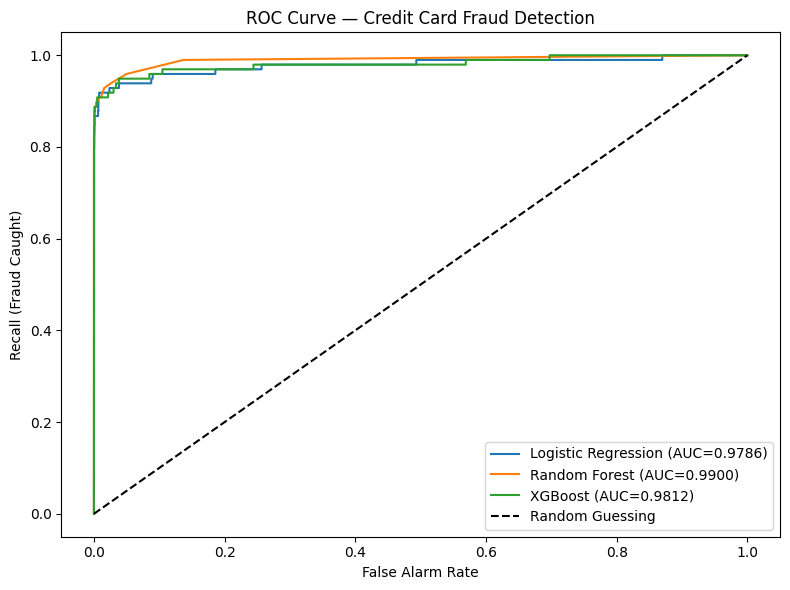

In [18]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, y_prob, auc in [
    ('Logistic Regression', y_prob_lr, 0.9786),
    ('Random Forest', y_prob_rf, 0.9900),
    ('XGBoost', y_prob_xgb, 0.9812)
]:
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0,1], [0,1], 'k--', label='Random Guessing')
plt.title('ROC Curve — Credit Card Fraud Detection')
plt.xlabel('False Alarm Rate')
plt.ylabel('Recall (Fraud Caught)')
plt.legend()
plt.tight_layout()
plt.show()

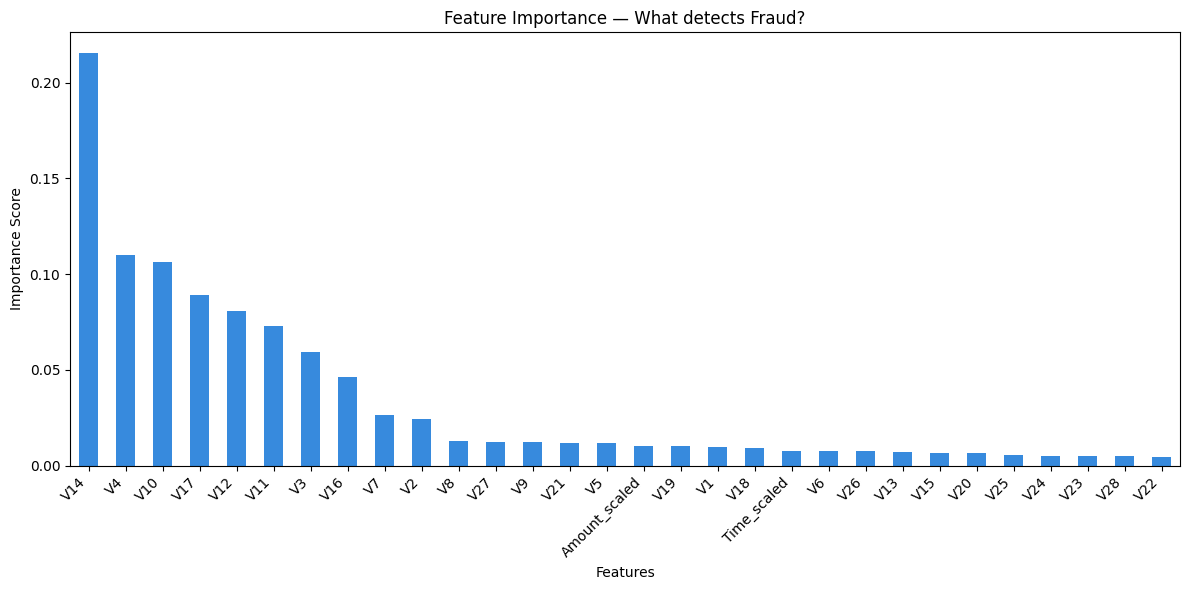

In [19]:
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
feature_importance.plot(kind='bar', color='#378ADD')
plt.title('Feature Importance — What detects Fraud?')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
xgb_tuned = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=66,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_tuned.fit(X_train_balanced, Y_train_balanced)
xgb_tuned_pred = xgb_tuned.predict(X_test)
print("✅ Tuned XGBoost trained!")

✅ Tuned XGBoost trained!


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 60)

for name, pred in [('XGBoost original', xgb_pred), 
                   ('XGBoost tuned', xgb_tuned_pred)]:
    acc  = accuracy_score(Y_test, pred)
    prec = precision_score(Y_test, pred)
    rec  = recall_score(Y_test, pred)
    f1   = f1_score(Y_test, pred)
    print(f"{name:<25} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")

Model                       Accuracy  Precision     Recall         F1
------------------------------------------------------------
XGBoost original              0.9992     0.7411     0.8469     0.7905
XGBoost tuned                 0.9973     0.3816     0.8878     0.5337


In [22]:
y_prob_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

print(f"{'Threshold':<15} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 40)

for threshold in [0.5, 0.4, 0.3, 0.2]:
    y_pred_t = (y_prob_tuned > threshold).astype(int)
    prec = precision_score(Y_test, y_pred_t)
    rec  = recall_score(Y_test, y_pred_t)
    f1   = f1_score(Y_test, y_pred_t)
    print(f"{str(threshold):<15} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")

Threshold        Precision     Recall         F1
----------------------------------------
0.5                 0.3816     0.8878     0.5337
0.4                 0.3271     0.8878     0.4780
0.3                 0.2719     0.8878     0.4163
0.2                 0.2206     0.8980     0.3541


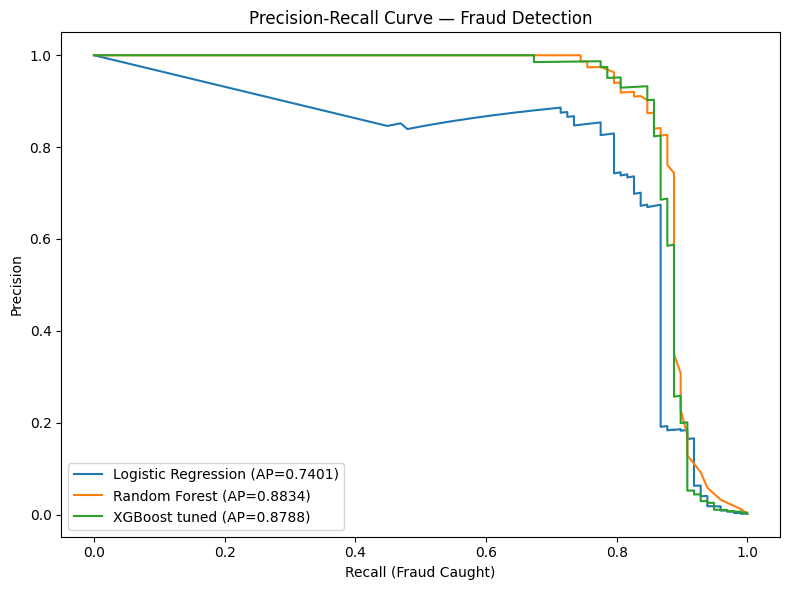

In [23]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

for name, y_prob in [
    ('Logistic Regression', lr.predict_proba(X_test)[:, 1]),
    ('Random Forest', rf.predict_proba(X_test)[:, 1]),
    ('XGBoost tuned', y_prob_tuned)
]:
    precision, recall, _ = precision_recall_curve(Y_test, y_prob)
    ap = average_precision_score(Y_test, y_prob)
    plt.plot(recall, precision, label=f'{name} (AP={ap:.4f})')

plt.title('Precision-Recall Curve — Fraud Detection')
plt.xlabel('Recall (Fraud Caught)')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.show()

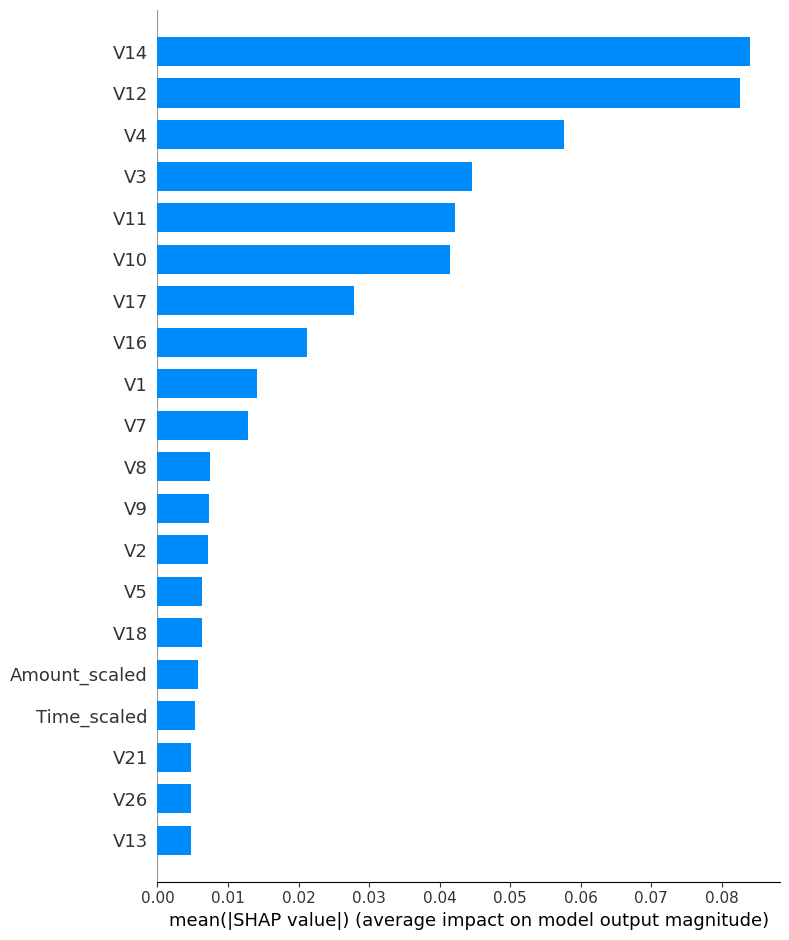

In [27]:
import shap

# Create SHAP explainer for Random Forest
explainer = shap.TreeExplainer(rf)

# Calculate SHAP values for test data (use small sample - faster)
X_test_sample = X_test.iloc[:100]
shap_values = explainer.shap_values(X_test_sample)

# Summary plot - shows most important features
shap.summary_plot(shap_values[:, :, 1], X_test_sample,
                  plot_type='bar',
                  show=False)
plt.tight_layout()
plt.show()

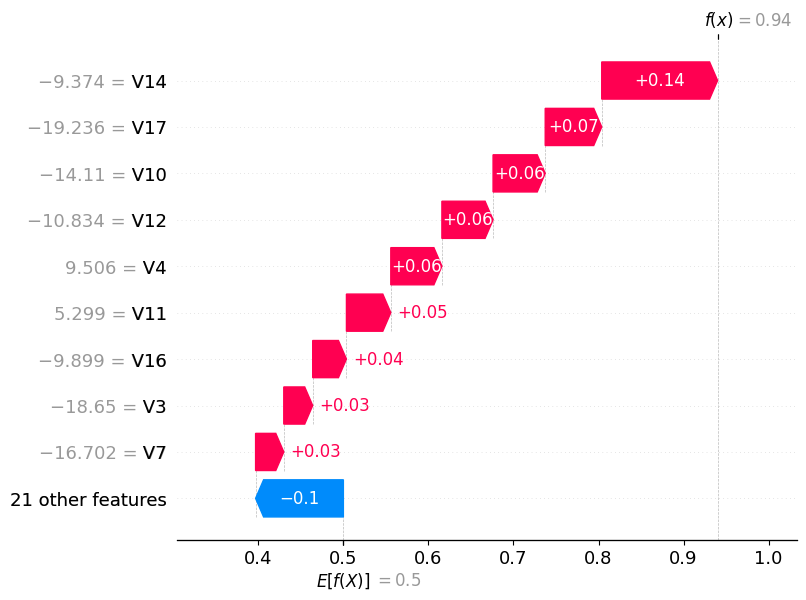

Transaction index: 43428
Actual label: 1
Fraud probability: 0.94

Transaction details:
V1              -16.526507
V2                8.584972
V3              -18.649853
V4                9.505594
V5              -13.793819
V6               -2.832404
V7              -16.701694
V8                7.517344
V9               -8.507059
V10             -14.110184
V11               5.299236
V12             -10.834006
V13               1.671120
V14              -9.373859
V15               0.360806
V16              -9.899247
V17             -19.236292
V18              -8.398552
V19               3.101735
V20              -1.514923
V21               1.190739
V22              -1.127670
V23              -2.358579
V24               0.673461
V25              -1.413700
V26              -0.462762
V27              -2.018575
V28              -1.042804
Amount_scaled     1.102834
Time_scaled      -1.122574
Name: 43428, dtype: float64


In [29]:
# Pick one fraud transaction
fraud_idx = Y_test[Y_test == 1].index[0]
fraud_transaction = X_test.loc[[fraud_idx]]

# Calculate SHAP values for this transaction
shap_single = explainer.shap_values(fraud_transaction)

# Waterfall plot - explains this specific transaction
shap.waterfall_plot(
    shap.Explanation(
        values=shap_single[0, :, 1],
        base_values=explainer.expected_value[1],
        data=fraud_transaction.iloc[0],
        feature_names=X_test.columns.tolist()
    )
)
print("Transaction index:", fraud_idx)
print("Actual label:", Y_test.loc[fraud_idx])
print("Fraud probability:", rf.predict_proba(X_test.loc[[fraud_idx]])[0][1])
print("\nTransaction details:")
print(X_test.loc[fraud_idx])

In [30]:
# confidence-based blocking logic:
def fraud_decision(probability):
    if probability >= 0.90:
        return "🔴 BLOCK — High fraud risk"
    elif probability >= 0.50:
        return "🟡 VERIFY — Send SMS confirmation"
    else:
        return "🟢 ALLOW — Transaction approved"

# Test on some transactions
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Sample transaction decisions:")
print("-" * 50)
for i in range(10):
    prob = y_prob_rf[i]
    decision = fraud_decision(prob)
    actual = Y_test.iloc[i]
    print(f"Transaction {i+1}: {prob:.2%} fraud → {decision} (Actual: {'Fraud' if actual==1 else 'Legit'})")

Sample transaction decisions:
--------------------------------------------------
Transaction 1: 94.00% fraud → 🔴 BLOCK — High fraud risk (Actual: Fraud)
Transaction 2: 0.00% fraud → 🟢 ALLOW — Transaction approved (Actual: Legit)
Transaction 3: 0.00% fraud → 🟢 ALLOW — Transaction approved (Actual: Legit)
Transaction 4: 0.00% fraud → 🟢 ALLOW — Transaction approved (Actual: Legit)
Transaction 5: 0.00% fraud → 🟢 ALLOW — Transaction approved (Actual: Legit)
Transaction 6: 0.00% fraud → 🟢 ALLOW — Transaction approved (Actual: Legit)
Transaction 7: 0.00% fraud → 🟢 ALLOW — Transaction approved (Actual: Legit)
Transaction 8: 0.00% fraud → 🟢 ALLOW — Transaction approved (Actual: Legit)
Transaction 9: 0.00% fraud → 🟢 ALLOW — Transaction approved (Actual: Legit)
Transaction 10: 0.00% fraud → 🟢 ALLOW — Transaction approved (Actual: Legit)


In [31]:
import joblib
import os

# Save model to correct folder
joblib.dump(rf, r'C:\Python\Projects\credit_card_fraud\fraud_model.pkl')
print("Model saved!")
print(os.path.exists(r'C:\Python\Projects\credit_card_fraud\fraud_model.pkl'))

Model saved!
True
